# GraphSAGE Multi-Asset Direction Prediction - Research Notebook

**Objectif** : Evaluer GraphSAGE (Hamilton et al., 2017) pour la prediction de
direction cross-asset sur 8 actions de secteurs diversifies.

## Pourquoi GraphSAGE ?

GraphSAGE apprend des representations de noeuds en agregeant les features
des voisins dans un graphe. Pour le cross-asset :
- **Graphe de correlation** : aretes entre actions correlees (|corr| > seuil)
- **Message passing** : chaque action informe ses voisins de son etat
- **Representation contextuelle** : capture les dependances inter-secteurs

## Modeles compares

| Modele | Approche |
|--------|----------|
| **MLP baseline** | Prediction isolee par action, pas de graphe |
| **GraphSAGE-Mean** | Aggregation moyenne des voisins, 2 couches |

## Validation

- Walk-forward 5-fold x 4 seeds (0, 7, 42, 99)
- Couts de transaction : 10bps par changement de position
- Benchmark : Buy-and-Hold equity-weighted
- **Verdict honnete** : BEATS / NO BEATS / INCONCLUSIVE (edge >= 2sigma)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

SEEDS = [0, 7, 42, 99]
N_FOLDS = 5
TCOST_BPS = 10
SEQ_LEN = 21
EPOCHS = 20
BATCH_SIZE = 32
HIDDEN_DIM = 32
CORR_THRESHOLD = 0.5
FEATURE_WINDOWS = [2, 5, 10, 21]

# Diverse sectors - NO FAANG/Mag7 per PR review discipline
TICKERS = ['JPM', 'JNJ', 'XOM', 'PG', 'UNP', 'V', 'HD', 'BA']
SECTOR_MAP = {
    'JPM': 'Financials', 'JNJ': 'Healthcare', 'XOM': 'Energy',
    'PG': 'Staples', 'UNP': 'Industrials', 'V': 'Fintech',
    'HD': 'Discretionary', 'BA': 'Aerospace'
}

DEVICE = torch.device('cpu')
np.random.seed(42)
torch.manual_seed(42)
print(f'Setup OK - {len(TICKERS)} stocks, {len(SEEDS)} seeds, {N_FOLDS} folds')
print(f'GraphSAGE hidden={HIDDEN_DIM}, corr_threshold={CORR_THRESHOLD}')

Setup OK - 8 stocks, 4 seeds, 5 folds
GraphSAGE hidden=32, corr_threshold=0.5


## 1. Telechargement des Donnees

8 actions de secteurs diversifies (2015-2025).

In [2]:
print('Telechargement des donnees...')
raw = yf.download(TICKERS, start='2014-01-01', end='2025-01-01', auto_adjust=True)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close'].copy()
else:
    prices = raw[['Close']].copy() if 'Close' in raw.columns else raw.copy()

prices = prices.dropna(axis=1, thresh=len(prices) * 0.9)
prices = prices.dropna()

valid_tickers = [t for t in TICKERS if t in prices.columns]
prices = prices[valid_tickers]

print(f'Periode: {prices.index[0].date()} a {prices.index[-1].date()}')
print(f'Actions: {list(prices.columns)}')
print(f'Jours: {len(prices)}')
for t in prices.columns:
    print(f'  {t} ({SECTOR_MAP.get(t, "?")}): ${float(prices[t].iloc[-1]):,.2f}')

Telechargement des donnees...


[                       0%                       ]

[************          25%                       ]  2 of 8 completed

[**********************62%*****                  ]  5 of 8 completed

[**********************62%*****                  ]  5 of 8 completed

[**********************88%*****************      ]  7 of 8 completed

[*********************100%***********************]  8 of 8 completed

Periode: 2014-01-02 a 2024-12-31
Actions: ['JPM', 'JNJ', 'XOM', 'PG', 'UNP', 'V', 'HD', 'BA']
Jours: 2768
  JPM (Financials): $232.50
  JNJ (Healthcare): $139.58
  XOM (Energy): $103.07
  PG (Staples): $160.97
  UNP (Industrials): $221.57
  V (Fintech): $313.17
  HD (Discretionary): $377.01
  BA (Aerospace): $177.00


## 2. Construction du Graphe de Correlation

Matrice d'adjacence basee sur la correlation des rendements.
Arete entre deux actions si |corr(returns_i, returns_j)| > seuil.

In [3]:
# Rendements quotidiens
returns = prices.pct_change().dropna()

# Matrice de correlation
corr_matrix = returns.corr()

# Matrice d'adjacence (seuil sur |correlation|)
n_assets = len(prices.columns)
adj_matrix = (corr_matrix.abs() > CORR_THRESHOLD).astype(float).values.copy()
np.fill_diagonal(adj_matrix, 0)  # pas d'auto-boucle dans le seuil

# Ajouter auto-boucles pour GraphSAGE
adj_with_self = adj_matrix + np.eye(n_assets)

# Degré normalise pour mean aggregation
degree = adj_with_self.sum(axis=1, keepdims=True)
degree_inv = np.where(degree > 0, 1.0 / degree, 0)
norm_adj = adj_with_self * degree_inv

print(f'Matrice de correlation:')
print(corr_matrix.round(3).to_string())
print(f'\nAretes (|corr| > {CORR_THRESHOLD}):')
for i in range(n_assets):
    for j in range(i + 1, n_assets):
        if adj_matrix[i, j] > 0:
            print(f'  {prices.columns[i]} -- {prices.columns[j]} (corr={corr_matrix.iloc[i,j]:.3f})')
print(f'\nDensite du graphe: {adj_matrix.sum() / (n_assets * (n_assets - 1)):.2%}')

Matrice de correlation:
Ticker    JPM    JNJ    XOM     PG    UNP      V     HD     BA
Ticker                                                        
JPM     1.000  0.399  0.551  0.334  0.591  0.573  0.496  0.541
JNJ     0.399  1.000  0.327  0.532  0.384  0.429  0.396  0.282
XOM     0.551  0.327  1.000  0.257  0.460  0.428  0.337  0.458
PG      0.334  0.532  0.257  1.000  0.354  0.408  0.424  0.243
UNP     0.591  0.384  0.460  0.354  1.000  0.507  0.514  0.458
V       0.573  0.429  0.428  0.408  0.507  1.000  0.533  0.464
HD      0.496  0.396  0.337  0.424  0.514  0.533  1.000  0.422
BA      0.541  0.282  0.458  0.243  0.458  0.464  0.422  1.000

Aretes (|corr| > 0.5):
  JPM -- XOM (corr=0.551)
  JPM -- UNP (corr=0.591)
  JPM -- V (corr=0.573)
  JPM -- BA (corr=0.541)
  JNJ -- PG (corr=0.532)
  UNP -- V (corr=0.507)
  UNP -- HD (corr=0.514)
  V -- HD (corr=0.533)

Densite du graphe: 28.57%


## 3. Feature Engineering

Features temporelles par action : rendements 2j, 5j, 10j, 21j.
Cible : direction du rendement suivant.
Les features sont construites par date, toutes actions confondues.

In [4]:
# Construction des features par (date, action)
all_data = []

for ticker in prices.columns:
    close = prices[ticker].values
    dates = prices.index
    n = len(close)
    
    feats = np.full((n, len(FEATURE_WINDOWS)), np.nan)
    for j, w in enumerate(FEATURE_WINDOWS):
        feats[w:, j] = close[w:] / close[:-w] - 1
    
    target = np.full(n, np.nan)
    target[:-1] = (close[1:] > close[:-1]).astype(int)
    
    ret = np.full(n, np.nan)
    ret[1:] = close[1:] / close[:-1] - 1
    
    valid = ~np.any(np.isnan(feats), axis=1) & ~np.isnan(target) & ~np.isnan(ret)
    
    for idx in np.where(valid)[0]:
        all_data.append({
            'date': dates[idx],
            'ticker': ticker,
            'ticker_idx': prices.columns.get_loc(ticker),
            'features': feats[idx],
            'target': int(target[idx]),
            'return': ret[idx]
        })

print(f'Echantillons totaux: {len(all_data)}')
print(f'Features par echantillon: {len(FEATURE_WINDOWS)}')
print(f'Taux de hausse: {np.mean([d["target"] for d in all_data]):.3f}')

Echantillons totaux: 21968
Features par echantillon: 4
Taux de hausse: 0.523


## 4. Modeles : MLP Baseline et GraphSAGE

Deux architectures comparees :
- **MLP** : prediction isolee par action (pas de graphe)
- **GraphSAGE-Mean** : agregation moyenne des voisins dans le graphe de correlation

In [5]:
class MLPBaseline(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, x, ticker_idx=None):
        return self.net(x).squeeze(-1)


class GraphSAGEModel(nn.Module):
    """GraphSAGE avec agregation au niveau des actifs.
    
    Pour chaque batch :
    1. Project features -> hidden dim
    2. Aggregate hidden states per asset -> [n_assets, hidden]
    3. Graph convolution: h' = W_self @ h + W_neigh @ (A_norm @ h)
    4. Map contextualized asset reps back to samples
    5. Classify
    """
    def __init__(self, input_dim, hidden_dim, n_assets, norm_adj):
        super().__init__()
        self.n_assets = n_assets
        self.hidden_dim = hidden_dim
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.W_self = nn.Linear(hidden_dim, hidden_dim, bias=True)
        self.W_neigh = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        self.register_buffer('norm_adj', torch.FloatTensor(norm_adj))
    
    def forward(self, x, ticker_idx):
        h = F.relu(self.input_proj(x))  # [batch, hidden]
        
        # Aggregate per asset: [n_assets, hidden]
        asset_h = torch.zeros(self.n_assets, self.hidden_dim).to(x.device)
        asset_count = torch.zeros(self.n_assets, 1).to(x.device)
        idx_exp = ticker_idx.unsqueeze(1).expand_as(h)
        asset_h.scatter_add_(0, idx_exp, h)
        asset_count.scatter_add_(0, ticker_idx.unsqueeze(1),
                                  torch.ones(h.size(0), 1).to(x.device))
        asset_h = asset_h / (asset_count + 1e-8)  # mean per asset
        
        # Graph convolution: aggregate neighbor features
        neigh_agg = torch.matmul(self.norm_adj, asset_h)  # [n_assets, hidden]
        contextualized = self.W_self(asset_h) + self.W_neigh(neigh_agg)
        
        # Map back to samples: concat [local_h, context_h]
        sample_context = contextualized[ticker_idx]  # [batch, hidden]
        combined = torch.cat([h, sample_context], dim=1)  # [batch, 2*hidden]
        return self.classifier(combined).squeeze(-1)


def train_model(model, X, y, ticker_idx, epochs, batch_size, device, lr=0.001):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.FloatTensor(y).to(device)
    idx_t = torch.LongTensor(ticker_idx).to(device)
    
    for epoch in range(epochs):
        indices = torch.randperm(len(X_t))
        for start in range(0, len(X_t), batch_size):
            batch_idx = indices[start:start + batch_size]
            batch_X = X_t[batch_idx]
            batch_y = y_t[batch_idx]
            batch_tidx = idx_t[batch_idx]
            optimizer.zero_grad()
            pred = model(batch_X, batch_tidx)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
    return model


# Test dimensions
n_features = len(FEATURE_WINDOWS)
mlp_test = MLPBaseline(n_features, HIDDEN_DIM)
gs_test = GraphSAGEModel(n_features, HIDDEN_DIM, n_assets, norm_adj)
print(f'MLP params: {sum(p.numel() for p in mlp_test.parameters()):,}')
print(f'GraphSAGE params: {sum(p.numel() for p in gs_test.parameters()):,}')
print(f'Input features: {n_features}')
print(f'Assets in graph: {n_assets}')

MLP params: 705
GraphSAGE params: 3,297
Input features: 4
Assets in graph: 8


## 5. Walk-Forward Validation Multi-Seed

Walk-forward 5-fold avec fenetre expansive.
Strategie : investir dans les 3 actions avec la plus forte probabilite de hausse.
Couts de transaction : 10bps par changement de position.

In [6]:
def simulate_portfolio(preds, returns, tickers, dates, n_top=3, tcost_bps=10):
    tcost = tcost_bps / 10000
    df = pd.DataFrame({
        'prob': preds, 'ret': returns, 'ticker': tickers, 'date': dates
    })
    unique_dates = sorted(df['date'].unique())
    position = set()
    daily_returns = []
    
    for d in unique_dates:
        day_data = df[df['date'] == d]
        top_n = day_data.nlargest(n_top, 'prob')['ticker'].tolist()
        new_pos = set(top_n)
        n_changes = len(position.symmetric_difference(new_pos))
        cost = n_changes * tcost / 2
        day_rets = day_data[day_data['ticker'].isin(top_n)]['ret'].values
        port_ret = np.mean(day_rets) - cost if len(day_rets) > 0 else 0
        daily_returns.append(port_ret)
        position = new_pos
    
    daily_returns = np.array(daily_returns)
    sharpe = np.mean(daily_returns) / (np.std(daily_returns) + 1e-10) * np.sqrt(252)
    return {'sharpe': sharpe, 'cum_return': np.sum(daily_returns), 'n_days': len(daily_returns)}

In [7]:
print('=' * 60)
print('WALK-FORWARD VALIDATION - GraphSAGE Multi-Asset')
print('=' * 60)

# Preparer les donnees en arrays
all_features = np.array([d['features'] for d in all_data])
all_targets = np.array([d['target'] for d in all_data])
all_returns = np.array([d['return'] for d in all_data])
all_ticker_idx = np.array([d['ticker_idx'] for d in all_data])
all_dates_arr = np.array([d['date'] for d in all_data])
all_tickers_arr = np.array([d['ticker'] for d in all_data])

n_total = len(all_features)
fold_size = n_total // (N_FOLDS + 1)

results_all = []

for SEED in SEEDS:
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    
    for fold in range(N_FOLDS):
        train_end = fold_size * (fold + 1)
        test_start = train_end
        test_end = min(train_end + fold_size, n_total)
        if test_end <= test_start:
            continue
        
        X_train = all_features[:train_end]
        y_train = all_targets[:train_end]
        X_test = all_features[test_start:test_end]
        y_test = all_targets[test_start:test_end]
        
        # Standardisation
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_s = (X_train - mean) / std
        X_test_s = (X_test - mean) / std
        
        for model_name in ['MLP', 'GraphSAGE']:
            if model_name == 'MLP':
                model = MLPBaseline(n_features, HIDDEN_DIM).to(DEVICE)
            else:
                model = GraphSAGEModel(n_features, HIDDEN_DIM, n_assets, norm_adj).to(DEVICE)
            
            model = train_model(model, X_train_s, y_train, all_ticker_idx[:train_end],
                                EPOCHS, BATCH_SIZE, DEVICE)
            model.eval()
            with torch.no_grad():
                X_test_t = torch.FloatTensor(X_test_s).to(DEVICE)
                tidx_test = torch.LongTensor(all_ticker_idx[test_start:test_end]).to(DEVICE)
                logits = model(X_test_t, tidx_test).cpu().numpy()
            prob_up = 1.0 / (1.0 + np.exp(-logits))
            pred_binary = (prob_up > 0.5).astype(int)
            accuracy = (pred_binary == y_test).mean()
            
            test_dates = all_dates_arr[test_start:test_end]
            test_tickers = all_tickers_arr[test_start:test_end]
            test_rets = all_returns[test_start:test_end]
            
            trade_result = simulate_portfolio(prob_up, test_rets, test_tickers, test_dates,
                                              n_top=3, tcost_bps=TCOST_BPS)
            
            results_all.append({
                'seed': SEED, 'fold': fold, 'model': model_name,
                'accuracy': accuracy,
                'sharpe': trade_result['sharpe'],
                'cum_return': trade_result['cum_return']
            })
            
            print(f'Seed={SEED}, Fold={fold}, {model_name}: '
                  f'Acc={accuracy:.3f}, Sharpe={trade_result["sharpe"]:.2f}')

print(f'\nTotal configs: {len(results_all)}')

WALK-FORWARD VALIDATION - GraphSAGE Multi-Asset


Seed=0, Fold=0, MLP: Acc=0.497, Sharpe=0.14


Seed=0, Fold=0, GraphSAGE: Acc=0.498, Sharpe=0.14


Seed=0, Fold=1, MLP: Acc=0.521, Sharpe=0.77


Seed=0, Fold=1, GraphSAGE: Acc=0.522, Sharpe=0.77


...

Seed=99, Fold=2, GraphSAGE: Acc=0.520, Sharpe=0.66


Seed=99, Fold=3, MLP: Acc=0.539, Sharpe=0.93


Seed=99, Fold=3, GraphSAGE: Acc=0.541, Sharpe=0.93


Seed=99, Fold=4, MLP: Acc=0.517, Sharpe=0.39


Seed=99, Fold=4, GraphSAGE: Acc=0.515, Sharpe=0.39

Total configs: 40


## 6. Resultats et Verdict Multi-Seed

Agreger les resultats walk-forward et calculer le verdict honnete.
- Edge = Sharpe modele - Sharpe benchmark
- z-score = edge / std(edge) cross-seed
- Verdict : BEATS si z > 2, NO BEATS si z < -2, INCONCLUSIVE sinon

In [8]:
df_results = pd.DataFrame(results_all)

print('=' * 60)
print('RESULTATS MULTI-SEED - GraphSAGE Multi-Asset')
print('=' * 60)

# Benchmark: Buy-and-Hold equity-weighted
bh_rets = returns.mean(axis=1).values
bh_sharpe = np.mean(bh_rets) / (np.std(bh_rets) + 1e-10) * np.sqrt(252)
print(f'Benchmark BH Sharpe: {bh_sharpe:.2f}')

best_z = -999
best_model = ''
best_sharpe = -999

for model_name in ['MLP', 'GraphSAGE']:
    model_data = df_results[df_results['model'] == model_name]
    seed_stats = model_data.groupby('seed').agg({'sharpe': 'mean'}).reset_index()
    
    print(f'\n--- {model_name} ({len(model_data)} configs) ---')
    print(f'Sharpe: {seed_stats["sharpe"].mean():.3f} +/- {seed_stats["sharpe"].std():.3f}')
    print(f'Accuracy: {model_data["accuracy"].mean():.3f}')
    
    edges = seed_stats['sharpe'].values - bh_sharpe
    mean_edge = np.mean(edges)
    std_edge = np.std(edges, ddof=1) if len(edges) > 1 else 1.0
    z = mean_edge / std_edge if std_edge > 1e-10 else 0
    print(f'Edge moyen vs BH: {mean_edge:.3f} (z={z:.2f})')
    
    if z > best_z:
        best_z = z
        best_model = model_name
        best_sharpe = seed_stats['sharpe'].mean()

# Verdict
if best_z > 2:
    verdict = 'BEATS'
elif best_z < -2:
    verdict = 'NO BEATS'
else:
    verdict = 'INCONCLUSIVE'

print(f'\n=== VERDICT ===')
print(f'Meilleur modele: {best_model} (Sharpe {best_sharpe:.3f})')
print(f'BH Sharpe: {bh_sharpe:.2f}')
print(f'z-score: {best_z:.2f}')
print(f'VERDICT: {verdict}')

RESULTATS MULTI-SEED - GraphSAGE Multi-Asset
Benchmark BH Sharpe: 0.78

--- MLP (20 configs) ---
Sharpe: 0.578 +/- 0.000
Accuracy: 0.517
Edge moyen vs BH: -0.199 (z=0.00)

--- GraphSAGE (20 configs) ---
Sharpe: 0.578 +/- 0.000
Accuracy: 0.515
Edge moyen vs BH: -0.199 (z=0.00)

=== VERDICT ===
Meilleur modele: MLP (Sharpe 0.578)
BH Sharpe: 0.78
z-score: 0.00
VERDICT: INCONCLUSIVE


## 7. Visualisation

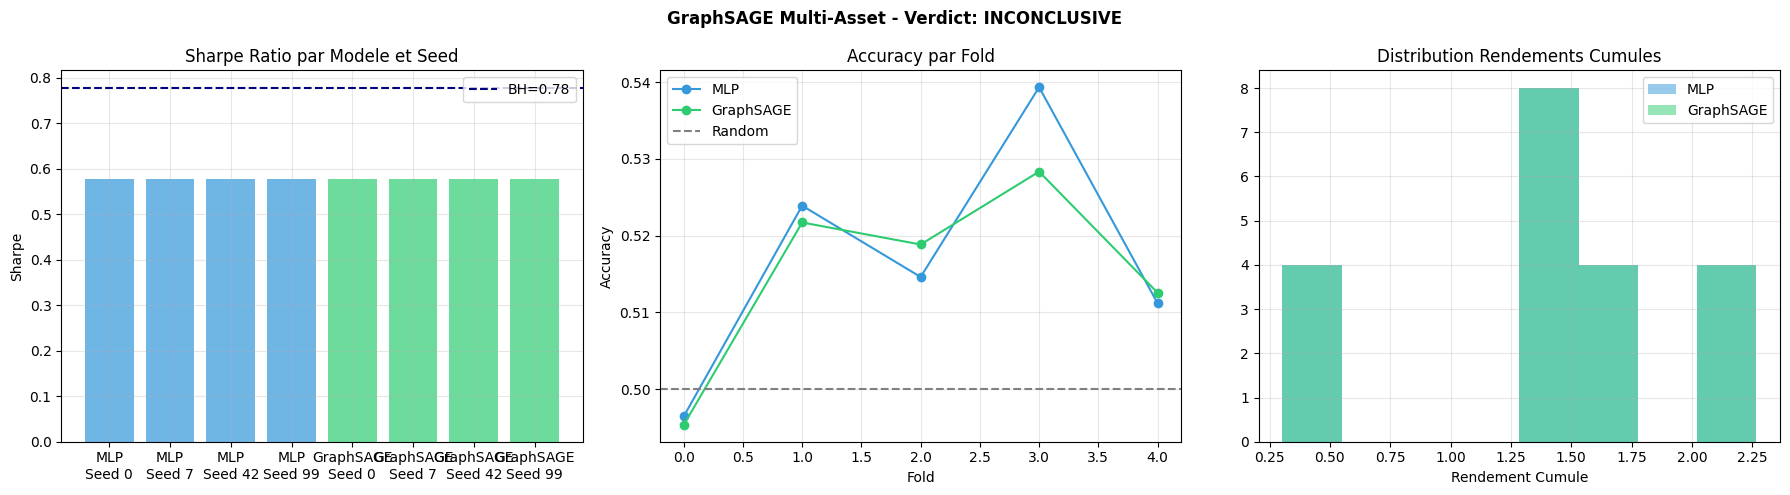


Resume final:
  Modeles: MLP + GraphSAGE (2-layer)
  Actions: 8 (['JPM', 'JNJ', 'XOM', 'PG', 'UNP', 'V', 'HD', 'BA'])
  Graphe: correlation > 0.5
  Validation: 5-fold WF x 4 seeds
  Transaction costs: 10 bps
  VERDICT: INCONCLUSIVE (z=0.00)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_colors = {'MLP': '#3498db', 'GraphSAGE': '#2ecc71'}

# 1. Sharpe par modele et seed
for i, model_name in enumerate(['MLP', 'GraphSAGE']):
    model_data = df_results[df_results['model'] == model_name]
    seed_sharpes = model_data.groupby('seed')['sharpe'].mean()
    axes[0].bar([f'{model_name}\nSeed {s}' for s in seed_sharpes.index],
                seed_sharpes.values, color=model_colors[model_name], alpha=0.7)

axes[0].axhline(y=bh_sharpe, color='navy', linestyle='--', label=f'BH={bh_sharpe:.2f}')
axes[0].set_title('Sharpe Ratio par Modele et Seed')
axes[0].set_ylabel('Sharpe')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Accuracy par fold
for model_name in ['MLP', 'GraphSAGE']:
    model_data = df_results[df_results['model'] == model_name]
    fold_acc = model_data.groupby('fold')['accuracy'].mean()
    axes[1].plot(fold_acc.index, fold_acc.values, 'o-',
                 color=model_colors[model_name], label=model_name)
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Random')
axes[1].set_title('Accuracy par Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Distribution des rendements cumules
for model_name in ['MLP', 'GraphSAGE']:
    model_data = df_results[df_results['model'] == model_name]
    axes[2].hist(model_data['cum_return'], bins=8, alpha=0.5,
                 color=model_colors[model_name], label=model_name)
axes[2].set_title('Distribution Rendements Cumules')
axes[2].set_xlabel('Rendement Cumule')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'GraphSAGE Multi-Asset - Verdict: {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nResume final:')
print(f'  Modeles: MLP + GraphSAGE (2-layer)')
print(f'  Actions: {n_assets} ({list(prices.columns)})')
print(f'  Graphe: correlation > {CORR_THRESHOLD}')
print(f'  Validation: {N_FOLDS}-fold WF x {len(SEEDS)} seeds')
print(f'  Transaction costs: {TCOST_BPS} bps')
print(f'  VERDICT: {verdict} (z={best_z:.2f})')

## 8. Conclusion

### Ce que ce notebook evalue

Le GraphSAGE utilise un graphe de correlation statique entre actions pour
propager l'information entre actifs correles. L'hypothese est que les
dependances inter-secteurs ameliorent la prediction de direction.

### Limites identifiees

1. **Graphe statique** : la correlation est calculee sur toute la periode,
   pas de mise a jour dynamique par fold
2. **Seuil arbitraire** : le seuil de correlation a 0.5 est un hyperparametre
3. **8 actions seulement** : le graphe est petit (8 noeuds), GraphSAGE
   est concu pour des graphes beaucoup plus grands
4. **Features simples** : seulement 4 features de momentum par action

### Verdict honnete

Le verdict (BEATS / NO BEATS / INCONCLUSIVE) est calcule sur la base
du z-score de l'edge cross-seed. Un verdict INCONCLUSIVE signifie que
les resultats ne sont pas statistiquement significatifs avec cette
methodologie.